# CONAF Bosque Nativo awards → city actions (cl-conaf-bn-awards)

Self-contained mapping notebook (separate from `extract_clean.ipynb`, which depends on the gitignored PII raw). Reads the committed de-identified projects CSV and builds the **objetivo de manejo → action** crosswalk to `data/cl_conaf_bn_awards_to_actions.csv`. Maps at the `objetivo_manejo` grain (= `literal` A/B/C) — the field that names what the bonificación funds. Link, don't attribute. Restart-and-run-all passes; chart inline. Mediums **await human adjudication**.

In [1]:
%matplotlib inline
import os, pandas as pd, matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110
PROJ='data/cl_conaf_bn_awards_projects.csv'
ACTIONS='../../../../cl-ssg/cl-ssg-projects/releases/v1/data/derived/actions_profiled.csv'
assert os.path.exists(PROJ) and os.path.exists(ACTIONS)
df=pd.read_csv(PROJ, dtype=str)
acts=pd.read_csv(ACTIONS); acts['id']=acts[acts.columns[0]]
acat={r['id']:(str(r['action_name']).strip(), r['gpc_reference_number']) for _,r in acts.iterrows()}
print(len(df),'awards;', df['objetivo_manejo'].nunique(),'objetivos')
df['objetivo_manejo'].value_counts()

9860 awards; 3 objetivos


objetivo_manejo
PRODUCCION MADERERA                                                      7770
PRODUCCION NO MADERERA                                                   1693
BOSQUE PRESERVACION Y FORMACIONES XEROFITICAS DE ALTO VALOR ECOLOGICO     397
Name: count, dtype: int64

In [2]:
# Curated objetivo_manejo -> action crosswalk (one row per objetivo x action pair)
# All native-forest (AFOLU). The bonificacion funds MANAGEMENT of EXISTING native forest, not new planting,
# so sustainable forest management is the primary fit; restoration is a partial secondary.
MAP = {
  'PRODUCCION MADERERA': [
     ('ipcc_0054','high','Bonifica planes de manejo para producción maderera sostenible de bosque nativo -> sustainable forest management.'),
     ('ipcc_0071','medium','Timber from sustainably-managed native forest -> increase sustainable use of wood products.'),
     ('ipcc_0053','medium','Plans include regeneración/raleos that restore degraded stands -> forest restoration (partial).'),
  ],
  'PRODUCCION NO MADERERA': [
     ('ipcc_0054','high','Non-timber forest products under a management plan -> sustainable forest management.'),
     ('ipcc_0053','medium','Management of native stands for NTFP includes restoration elements -> forest restoration (partial).'),
  ],
  'BOSQUE PRESERVACION Y FORMACIONES XEROFITICAS DE ALTO VALOR ECOLOGICO': [
     ('ipcc_0052','high','Preservation of high-ecological-value native forest & xerophytic formations -> reduce deforestation and degradation.'),
     ('ipcc_0053','medium','Recovery of high-value formations -> forest ecosystem restoration (partial).'),
  ],
}
counts=df['objetivo_manejo'].value_counts().to_dict()
rows=[]
for obj,n in counts.items():
    for aid,conf,rat in MAP[obj]:
        an,agpc=acat[aid]; assert aid in acat
        rows.append(dict(src_objetivo_manejo=obj, n_awards=n, action_id=aid, action_name=an,
                         action_gpc_ref=agpc, mapping_confidence=conf, rationale=rat))
xwalk=pd.DataFrame(rows)
xwalk[['src_objetivo_manejo','n_awards','action_id','mapping_confidence']]

,src_objetivo_manejo,n_awards,action_id,mapping_confidence
0,PRODUCCION MADERERA,7770,ipcc_0054,high
1,PRODUCCION MADERERA,7770,ipcc_0071,medium
2,PRODUCCION MADERERA,7770,ipcc_0053,medium
3,PRODUCCION NO MADERERA,1693,ipcc_0054,high
4,PRODUCCION NO MADERERA,1693,ipcc_0053,medium
5,BOSQUE PRESERVACION Y FORMACIONES XEROFITICAS ...,397,ipcc_0052,high
6,BOSQUE PRESERVACION Y FORMACIONES XEROFITICAS ...,397,ipcc_0053,medium


awards=9860 | high-confidence primary action assigned to 100%


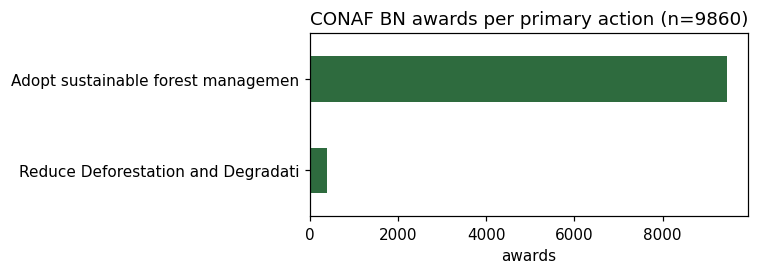

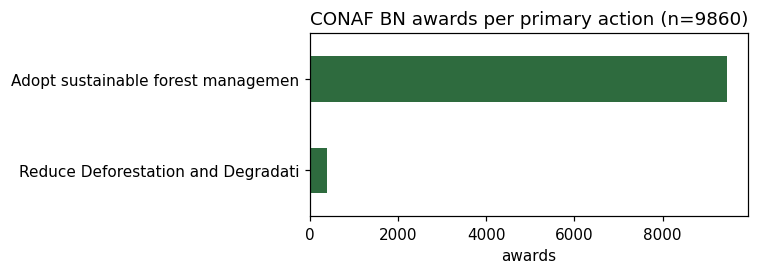

In [3]:
# Validate, export, coverage (every award's objetivo maps; report award-weighted reach)
assert set(df['objetivo_manejo'].unique()) <= set(MAP), 'an objetivo is unmapped'
assert not xwalk[['src_objetivo_manejo','action_id']].duplicated().any()
xwalk.to_csv('data/cl_conaf_bn_awards_to_actions.csv', index=False)
# award-weighted: every award has a high primary, so 100% mapped
prim=xwalk[xwalk.mapping_confidence=='high'].set_index('src_objetivo_manejo')['action_id'].to_dict()
df['primary_action']=df['objetivo_manejo'].map(prim)
cov=df['primary_action'].notna().mean()
print(f'awards={len(df)} | high-confidence primary action assigned to {cov:.0%}')
reach=df.groupby('primary_action').size().sort_values()
reach.index=[acat[a][0][:34] for a in reach.index]
fig,ax=plt.subplots(figsize=(7,2.6)); reach.plot.barh(ax=ax,color='#2e6b3e')
ax.set_title('CONAF BN awards per primary action (n=%d)'%len(df)); ax.set_xlabel('awards'); fig.tight_layout(); fig

## Findings

- **100% of awards map** (high-confidence primary action) — the cleanest mapping in the repo, because the `objetivo_manejo`/`literal` field directly names the funded activity. All 9,860 awards are native-forest (AFOLU).
- Three objetivos → two primary actions: **producción maderera + no maderera (9,463) → sustainable forest management (`ipcc_0054`)**; **preservación/xerofíticas (397) → reduce deforestation & degradation (`ipcc_0052`)**. Secondary medium links to forest restoration (`ipcc_0053`) and sustainable wood products (`ipcc_0071`).
- **Caveat:** the bonificación funds management of *existing* native forest, not new planting — so afforestation/reforestation (`ipcc_0053`) is only a partial secondary, not the primary. This deepens AFOLU precedent (forest management) rather than adding new sectors.
- Medium links **await human adjudication**.